# Equipment Utilization & Activity Classification

**Pipeline:** YouTube → Frame extraction → Optical Flow (articulated) → ResNet+LSTM activity model → Inference → Kafka → PostgreSQL → Streamlit

---

## 1. Install Dependencies

In [1]:
!pip install -q ultralytics kafka-python yt-dlp psycopg2-binary opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.3/326.3 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 76.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 75.0 MB/s eta 0:00:00:00:01


## 2. Imports & Configuration

In [2]:
import os
import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

from ultralytics import YOLO

# ── Paths ──────────────────────────────────────────────────────
INPUT_VIDEOS_PATH  = "/kaggle/input/datasets/mahmoudosamahassan/equipment-utilization-and-activity-classification/videos/"
OUTPUT_DATASET_PATH = "/kaggle/working/dataset/"

# ── Constants ─────────────────────────────────────────────────
ACTIVITIES   = ["DIGGING", "SWINGING", "DUMPING"]   # WAITING is handled separately (INACTIVE state)
LABEL_MAP    = {a: i for i, a in enumerate(ACTIVITIES)}
NUM_FRAMES   = 8       # frames per clip fed to the model
CLIP_SIZE    = 16      # frames extracted per clip from video
CLIP_STRIDE  = 8       # stride between clips
EXTRACT_FPS  = 2       # fps for frame extraction
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cuda


---
## 3. Download Videos from YouTube

In [3]:
# YOUTUBE_URLS = [
#     "https://youtu.be/0SlUM1anZa8?si=D9_WNjxBKF41WBPH",
#     "https://youtu.be/BKiNmPHRHJc?si=ByneDiZaEBJvp_qh",
#     # Add more URLs here
# ]

# os.makedirs("/kaggle/working/videos", exist_ok=True)

# with open("urls.txt", "w") as f:
#     f.write("\n".join(YOUTUBE_URLS))

# !yt-dlp -a urls.txt \
#     -f "mp4[height<=720]" \
#     --restrict-filenames \
#     --autonumber-start 1 \
#     -o "/kaggle/working/videos/video_%(autonumber)s.%(ext)s"

---
## 4. Load YOLO Model

In [3]:
yolo_model = YOLO("yolov8m.pt")
print("YOLO loaded — class names:", list(yolo_model.names.values())[:10])

YOLO loaded — class names: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']


---
## 5. Frame & Clip Extraction

For each video:
1. Extract frames at 2 fps
2. Detect whether any excavator/truck is visible
3. Save only clips that contain equipment (skip empty scenes)

In [4]:
def extract_frames(video_path, frames_folder, fps=EXTRACT_FPS):
    """Extract frames from a video at the given fps rate."""
    os.makedirs(frames_folder, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    original_fps = cap.get(cv2.CAP_PROP_FPS) or 25
    interval = max(1, int(original_fps / fps))
    frame_count = saved_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_count % interval == 0:
            frame = cv2.resize(frame, (640, 360))
            cv2.imwrite(os.path.join(frames_folder, f"frame_{saved_count:05d}.jpg"), frame)
            saved_count += 1
        frame_count += 1

    cap.release()
    return saved_count


def has_equipment(frame, yolo_model, conf_th=0.3):
    """Return True if an excavator or truck is detected in the frame."""
    results = yolo_model(frame, verbose=False)[0]
    for box in results.boxes:
        if float(box.conf[0]) > conf_th and yolo_model.names[int(box.cls[0])] in ["truck", "car", "bus"]:
            return True
    return False


def create_clips(frames_folder, clips_folder, yolo_model, clip_size=CLIP_SIZE, stride=CLIP_STRIDE):
    """Slice frames into overlapping clips, keeping only those with equipment."""
    os.makedirs(clips_folder, exist_ok=True)
    frames = sorted(os.listdir(frames_folder))
    clip_id = 0

    for i in range(0, len(frames) - clip_size, stride):
        # Check 3 frames spread across the clip for efficiency
        check_idxs = [i, i + clip_size // 2, i + clip_size - 1]
        if not any(has_equipment(cv2.imread(os.path.join(frames_folder, frames[j])), yolo_model)
                   for j in check_idxs):
            continue

        clip_folder = os.path.join(clips_folder, f"clip_{clip_id:05d}")
        os.makedirs(clip_folder, exist_ok=True)
        for j in range(clip_size):
            src = os.path.join(frames_folder, frames[i + j])
            dst = os.path.join(clip_folder, f"frame_{j:02d}.jpg")
            cv2.imwrite(dst, cv2.imread(src))
        clip_id += 1

    return clip_id

In [5]:
# Process all videos
video_files = [f for f in os.listdir(INPUT_VIDEOS_PATH) if f.endswith(".mp4")]
print(f"Found {len(video_files)} videos")

for video_file in tqdm(video_files):
    name          = os.path.splitext(video_file)[0]
    video_path    = os.path.join(INPUT_VIDEOS_PATH, video_file)
    frames_folder = os.path.join(OUTPUT_DATASET_PATH, name, "frames")
    clips_folder  = os.path.join(OUTPUT_DATASET_PATH, name, "clips")
    labels_folder = os.path.join(OUTPUT_DATASET_PATH, name, "labels")

    os.makedirs(labels_folder, exist_ok=True)

    n_frames = extract_frames(video_path, frames_folder)
    n_clips  = create_clips(frames_folder, clips_folder, yolo_model)
    print(f"  {name}: {n_frames} frames → {n_clips} clips")

Found 2 videos


 50%|█████     | 1/2 [00:39<00:39, 39.69s/it]

  video_00002: 1729 frames → 215 clips


100%|██████████| 2/2 [01:32<00:00, 46.30s/it]

  video_00001: 2501 frames → 288 clips


### Preview a Clip

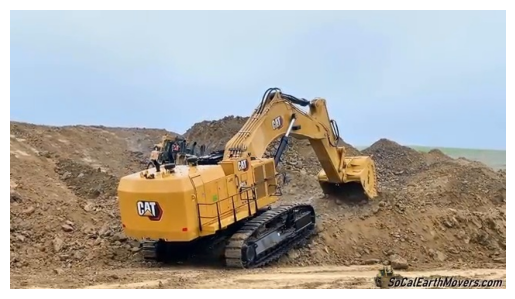

In [6]:
def preview_clip(clip_folder, delay=0.1):
    """Display frames of a clip inline in the notebook."""
    for f in sorted(os.listdir(clip_folder)):
        img = cv2.cvtColor(cv2.imread(os.path.join(clip_folder, f)), cv2.COLOR_BGR2RGB)
        plt.imshow(img); plt.axis("off")
        display(plt.gcf()); clear_output(wait=True)
        time.sleep(delay)

# Change this path to any clip you want to inspect
preview_clip("/kaggle/working/dataset/video_00001/clips/clip_00013")

---
## 6. Motion Analysis — Optical Flow (Articulated)

The key challenge is detecting motion when **only a part** of the machine moves (e.g., arm digging while tracks are still). We solve this by splitting the bounding box into upper (arm) and lower (tracks) regions and computing optical flow independently for each.

In [7]:
def get_clip_bbox(clip_folder, yolo_model, conf_th=0.3):
    """Get a stable bounding box from the middle frame of a clip."""
    frames = sorted(os.listdir(clip_folder))
    mid    = cv2.imread(os.path.join(clip_folder, frames[len(frames) // 2]))
    results = yolo_model(mid, verbose=False)[0]
    best_box, best_conf = None, 0

    for box in results.boxes:
        conf  = float(box.conf[0])
        label = yolo_model.names[int(box.cls[0])]
        if label in ["truck", "car", "bus"] and conf > best_conf and conf > conf_th:
            best_conf = conf
            best_box  = tuple(map(int, box.xyxy[0]))
    return best_box


def crop_roi(frame, bbox, expand=0.1):
    """Crop and slightly expand the bounding box from the frame."""
    if bbox is None:
        return None
    x1, y1, x2, y2 = bbox
    h, w = frame.shape[:2]
    pad_x = int((x2 - x1) * expand)
    pad_y = int((y2 - y1) * expand)
    x1, y1 = max(0, x1 - pad_x), max(0, y1 - pad_y)
    x2, y2 = min(w, x2 + pad_x), min(h, y2 + pad_y)
    return frame[y1:y2, x1:x2]


def split_roi(roi):
    """Split ROI horizontally: upper = arm/boom, lower = tracks/wheels."""
    h = roi.shape[0]
    return roi[:h // 2, :], roi[h // 2:, :]


def compute_optical_flow(prev_gray, curr_gray):
    """Compute mean optical flow magnitude between two grayscale frames."""
    try:
        prev_gray = cv2.GaussianBlur(prev_gray, (5, 5), 0)
        curr_gray = cv2.GaussianBlur(curr_gray, (5, 5), 0)
        flow = cv2.calcOpticalFlowFarneback(prev_gray, curr_gray, None, 0.5, 3, 15, 3, 5, 1.2, 0)
        return float(np.mean(np.sqrt(flow[..., 0]**2 + flow[..., 1]**2)))
    except:
        return 0.0


def motion_from_clip_articulated(clip_folder, yolo_model):
    """
    Compute upper and lower region motion scores across a clip.
    Returns (motion_upper, motion_lower).
    """
    frames = sorted(os.listdir(clip_folder))
    bbox   = get_clip_bbox(clip_folder, yolo_model)
    if bbox is None:
        return 0.0, 0.0

    prev_upper = prev_lower = None
    motions_upper, motions_lower = [], []

    for f in frames:
        frame = cv2.imread(os.path.join(clip_folder, f))
        roi   = crop_roi(frame, bbox)
        if roi is None:
            continue
        roi = cv2.resize(roi, (128, 128))
        upper, lower = split_roi(roi)
        gu = cv2.cvtColor(upper, cv2.COLOR_BGR2GRAY)
        gl = cv2.cvtColor(lower, cv2.COLOR_BGR2GRAY)

        if prev_upper is not None:
            motions_upper.append(compute_optical_flow(prev_upper, gu))
            motions_lower.append(compute_optical_flow(prev_lower, gl))
        prev_upper, prev_lower = gu, gl

    m_up  = float(np.median(motions_upper)) if motions_upper else 0.0
    m_low = float(np.median(motions_lower)) if motions_lower else 0.0
    return m_up, m_low


def get_state_articulated(m_up, m_low, th_arm=0.3, th_tracks=0.5):
    """
    Classify machine state based on region-level motion.
    Returns (state, motion_source).
    """
    if m_up > th_arm and m_low > th_tracks:
        return "ACTIVE", "both"
    if m_up > th_arm:
        return "ACTIVE", "arm_only"
    if m_low > th_tracks:
        return "ACTIVE", "tracks_only"
    return "INACTIVE", "none"

In [8]:
# Quick sanity check on one clip
clip_folder = "/kaggle/working/dataset/video_00002/clips/clip_00051"
m_up, m_low = motion_from_clip_articulated(clip_folder, yolo_model)
state, source = get_state_articulated(m_up, m_low)

print(f"Upper motion : {m_up:.4f}")
print(f"Lower motion : {m_low:.4f}")
print(f"State        : {state}")
print(f"Motion source: {source}")

Upper motion : 5.4590
Lower motion : 5.4251
State        : ACTIVE
Motion source: both


---
## 7. Labeling

**Strategy:**
- INACTIVE clips → auto-labeled as `WAITING`
- ACTIVE clips → labeled as `UNKNOWN`, then manually reviewed and corrected
- Manual labels are stored in a separate Kaggle dataset and merged here

In [9]:
def process_video_motion(dataset_path, vid, yolo_model):
    """Run motion analysis on all clips of one video. Returns a DataFrame."""
    clips_path = os.path.join(dataset_path, vid, "clips")
    results = []

    for clip in tqdm(sorted(os.listdir(clips_path)), desc=vid, leave=False):
        clip_path = os.path.join(clips_path, clip)
        m_up, m_low = motion_from_clip_articulated(clip_path, yolo_model)
        state, source = get_state_articulated(m_up, m_low)
        results.append({"clip_id": clip, "state": state, "motion_source": source,
                         "motion_upper": round(m_up, 4), "motion_lower": round(m_low, 4)})

    return pd.DataFrame(results)


# Run and save motion results
for vid in os.listdir(OUTPUT_DATASET_PATH):
    save_path = os.path.join(OUTPUT_DATASET_PATH, vid, "labels")
    os.makedirs(save_path, exist_ok=True)
    df = process_video_motion(OUTPUT_DATASET_PATH, vid, yolo_model)
    df.to_csv(os.path.join(save_path, "motion_results.csv"), index=False)
    del df

In [10]:
def generate_auto_labels(dataset_path, vid):
    """Convert motion results to initial labels: INACTIVE→WAITING, ACTIVE→UNKNOWN."""
    motion_path = os.path.join(dataset_path, vid, "labels", "motion_results.csv")
    if not os.path.exists(motion_path):
        return

    df = pd.read_csv(motion_path)
    df["activity"] = df["state"].apply(lambda s: "WAITING" if s == "INACTIVE" else "UNKNOWN")
    df[["clip_id", "activity"]].to_csv(
        os.path.join(dataset_path, vid, "labels", "labels_auto.csv"), index=False)
    print(f"  Auto labels saved: {vid}  ({(df.activity=='UNKNOWN').sum()} clips need manual review)")


for vid in os.listdir(OUTPUT_DATASET_PATH):
    generate_auto_labels(OUTPUT_DATASET_PATH, vid)

  Auto labels saved: video_00002  (206 clips need manual review)
  Auto labels saved: video_00001  (216 clips need manual review)


In [11]:
def create_manual_review_file(dataset_path, vid):
    """Extract only UNKNOWN clips into a separate file for manual labeling."""
    auto_path = os.path.join(dataset_path, vid, "labels", "labels_auto.csv")
    if not os.path.exists(auto_path):
        return
    df = pd.read_csv(auto_path)
    df[df["activity"] == "UNKNOWN"].to_csv(
        os.path.join(dataset_path, vid, "labels", "labels_manual.csv"), index=False)
    print(f"  Manual file created: {vid}")

for vid in os.listdir(OUTPUT_DATASET_PATH):
    create_manual_review_file(OUTPUT_DATASET_PATH, vid)

  Manual file created: video_00002
  Manual file created: video_00001


In [12]:
# Paths to your manually labeled CSVs (uploaded as Kaggle datasets)
MANUAL_LABEL_SOURCES = {
    "video_00001": "/kaggle/input/datasets/mahmoudosamahassan/labels-manual-new-v1/labels_manual.csv",
    "video_00002": "/kaggle/input/datasets/mahmoudosamahassan/labels-manual-new-v2/labels_manual.csv",
}


def merge_labels(dataset_path, vid, manual_path):
    """Merge auto labels with manual corrections into final labels.csv."""
    auto_path = os.path.join(dataset_path, vid, "labels", "labels_auto.csv")
    if not os.path.exists(auto_path):
        print(f"No auto labels for {vid}"); return

    df_auto   = pd.read_csv(auto_path)
    df_manual = pd.read_csv(manual_path) if os.path.exists(manual_path) else pd.DataFrame()

    manual_dict = dict(zip(df_manual["clip_id"].astype(str), df_manual["activity"]))                   if not df_manual.empty else {}

    df_auto["clip_id"]  = df_auto["clip_id"].astype(str)
    df_auto["activity"] = df_auto.apply(
        lambda r: manual_dict.get(r["clip_id"], r["activity"]), axis=1)

    # Drop any remaining UNKNOWN rows
    df_final = df_auto[df_auto["activity"] != "UNKNOWN"]
    df_final.to_csv(os.path.join(dataset_path, vid, "labels", "labels.csv"), index=False)
    print(f"  Merged: {vid}  ({len(df_final)} clips, distribution: {df_final.activity.value_counts().to_dict()})")


for vid, manual_path in MANUAL_LABEL_SOURCES.items():
    merge_labels(OUTPUT_DATASET_PATH, vid, manual_path)

  Merged: video_00001  (281 clips, distribution: {'DIGGING': 98, 'SWINGING': 91, 'DUMPING': 80, 'WAITING': 12})
  Merged: video_00002  (209 clips, distribution: {'SWINGING': 88, 'DIGGING': 68, 'DUMPING': 50, 'WAITING': 3})


---
## 8. Build Training Dataset

In [13]:
all_samples = []

for vid in os.listdir(OUTPUT_DATASET_PATH):
    labels_path = os.path.join(OUTPUT_DATASET_PATH, vid, "labels", "labels.csv")
    if not os.path.exists(labels_path):
        continue
    df = pd.read_csv(labels_path)
    for _, row in df.iterrows():
        clip_folder = os.path.join(OUTPUT_DATASET_PATH, vid, "clips", row["clip_id"])
        if os.path.exists(clip_folder):
            all_samples.append((clip_folder, row["activity"]))

df_all = pd.DataFrame(all_samples, columns=["clip_folder", "activity"])
df_all["label"] = df_all["activity"].map(LABEL_MAP)
df_all = df_all.dropna(subset=["label"])
df_all["label"] = df_all["label"].astype(int)

print(f"Total samples: {len(df_all)}")
print(df_all["activity"].value_counts())

Total samples: 475
activity
SWINGING    179
DIGGING     166
DUMPING     130
Name: count, dtype: int64


In [14]:
train_df, val_df = train_test_split(
    df_all, test_size=0.2, stratify=df_all["label"], random_state=42)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}")

Train: 380  |  Val: 95


In [15]:
class ClipDataset(Dataset):
    """Loads a clip folder and returns a (C, T, H, W) tensor + label."""

    def __init__(self, df, num_frames=NUM_FRAMES):
        self.df = df.reset_index(drop=True)
        self.num_frames = num_frames

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row          = self.df.iloc[idx]
        clip_folder  = row["clip_folder"]
        label        = int(row["label"])
        frames       = sorted(os.listdir(clip_folder))

        # Sample or pad to exactly num_frames
        if len(frames) >= self.num_frames:
            frames = frames[:self.num_frames]
        else:
            frames = frames + [frames[-1]] * (self.num_frames - len(frames))

        clip = []
        for f in frames:
            img = cv2.imread(os.path.join(clip_folder, f))
            img = cv2.resize(img, (112, 112))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            clip.append(img.astype(np.float32) / 255.0)

        clip = np.stack(clip).transpose(3, 0, 1, 2)   # (C, T, H, W)
        return torch.tensor(clip), torch.tensor(label)


train_loader = DataLoader(ClipDataset(train_df), batch_size=4, shuffle=True,  num_workers=2)
val_loader   = DataLoader(ClipDataset(val_df),   batch_size=4, shuffle=False, num_workers=2)
print("Dataloaders ready")

Dataloaders ready


---
## 9. Model Architecture

Two architectures are compared:
- **ResNet18 + LSTM** — captures temporal ordering of frames via LSTM hidden state
- **ResNet18 + TemporalAvgPool** — simpler, faster; averages frame features across time

The simpler model achieved **63% validation accuracy** vs 58% for LSTM on this small dataset, so it is saved as the production model.

In [16]:
class ResNetLSTM(nn.Module):
    """ResNet18 backbone with LSTM temporal modeling."""

    def __init__(self, num_classes=3):
        super().__init__()
        self.backbone = models.resnet18(pretrained=True)
        self.backbone.fc = nn.Identity()
        self.lstm       = nn.LSTM(512, 256, batch_first=True)
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):           # x: (B, C, T, H, W)
        B, C, T, H, W = x.shape
        x    = x.permute(0,2,1,3,4).reshape(B*T, C, H, W)
        feats = self.backbone(x).view(B, T, -1)
        _, (h, _) = self.lstm(feats)
        return self.classifier(h[-1])


class ResNetAvgPool(nn.Module):
    """ResNet18 backbone with temporal average pooling (simpler & faster)."""

    def __init__(self, num_classes=3):
        super().__init__()
        self.backbone   = models.resnet18(pretrained=True)
        self.backbone.fc = nn.Identity()
        self.classifier  = nn.Linear(512, num_classes)

    def forward(self, x):           # x: (B, C, T, H, W)
        B, C, T, H, W = x.shape
        x    = x.permute(0,2,1,3,4).reshape(B*T, C, H, W)
        feats = self.backbone(x).view(B, T, -1).mean(dim=1)   # temporal avg
        return self.classifier(feats)

### 9.1 Train ResNet18 + LSTM

In [17]:
lstm_model = ResNetLSTM(num_classes=3).to(DEVICE)

# Freeze backbone — only train LSTM + classifier
for p in lstm_model.backbone.parameters():
    p.requires_grad = False

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, lstm_model.parameters()), lr=5e-5)
criterion = nn.CrossEntropyLoss()

for epoch in range(20):
    lstm_model.train()
    total_loss = 0
    for clips, labels in train_loader:
        clips, labels = clips.to(DEVICE), labels.to(DEVICE)
        loss = criterion(lstm_model(clips), labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch:02d} | Loss: {total_loss / len(train_loader):.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 159MB/s]


Epoch 00 | Loss: 1.0946
Epoch 01 | Loss: 1.0705
Epoch 02 | Loss: 1.0449
Epoch 03 | Loss: 1.0209
Epoch 04 | Loss: 0.9964
Epoch 05 | Loss: 0.9722
Epoch 06 | Loss: 0.9441
Epoch 07 | Loss: 0.9264
Epoch 08 | Loss: 0.8857
Epoch 09 | Loss: 0.8712
Epoch 10 | Loss: 0.8392
Epoch 11 | Loss: 0.8106
Epoch 12 | Loss: 0.7761
Epoch 13 | Loss: 0.7263
Epoch 14 | Loss: 0.7171
Epoch 15 | Loss: 0.6784
Epoch 16 | Loss: 0.6656
Epoch 17 | Loss: 0.6562
Epoch 18 | Loss: 0.6351
Epoch 19 | Loss: 0.6557


In [18]:
lstm_model.eval()
correct = total = 0
with torch.no_grad():
    for clips, labels in val_loader:
        preds = lstm_model(clips.to(DEVICE)).argmax(1).cpu()
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
print(f"ResNet+LSTM  Validation Accuracy: {correct/total:.4f}  ({correct}/{total})")

ResNet+LSTM  Validation Accuracy: 0.6105  (58/95)


### 9.2 Train ResNet18 + TemporalAvgPool

In [19]:
avg_model = ResNetAvgPool(num_classes=3).to(DEVICE)

# Freeze backbone
for p in avg_model.backbone.parameters():
    p.requires_grad = False

optimizer = torch.optim.Adam(avg_model.classifier.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

for epoch in range(20):
    avg_model.train()
    total_loss = 0
    for clips, labels in train_loader:
        clips, labels = clips.to(DEVICE), labels.to(DEVICE)
        loss = criterion(avg_model(clips), labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch:02d} | Loss: {total_loss / len(train_loader):.4f}")

Epoch 00 | Loss: 1.1499
Epoch 01 | Loss: 1.1362
Epoch 02 | Loss: 1.1120
Epoch 03 | Loss: 1.0958
Epoch 04 | Loss: 1.0847
Epoch 05 | Loss: 1.0938
Epoch 06 | Loss: 1.0696
Epoch 07 | Loss: 1.0698
Epoch 08 | Loss: 1.0682
Epoch 09 | Loss: 1.0443
Epoch 10 | Loss: 1.0368
Epoch 11 | Loss: 1.0516
Epoch 12 | Loss: 1.0647
Epoch 13 | Loss: 1.0366
Epoch 14 | Loss: 1.0301
Epoch 15 | Loss: 1.0387
Epoch 16 | Loss: 1.0241
Epoch 17 | Loss: 1.0300
Epoch 18 | Loss: 1.0166
Epoch 19 | Loss: 1.0155


In [20]:
avg_model.eval()
correct = total = 0
with torch.no_grad():
    for clips, labels in val_loader:
        preds = avg_model(clips.to(DEVICE)).argmax(1).cpu()
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
print(f"ResNet+AvgPool Validation Accuracy: {correct/total:.4f}  ({correct}/{total})")

ResNet+AvgPool Validation Accuracy: 0.4316  (41/95)


In [24]:
class SimpleVideoModel(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.backbone = models.resnet18(pretrained=True)
        self.backbone.fc = nn.Identity()

        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):  # (B, C, T, H, W)
        B, C, T, H, W = x.shape

        x = x.permute(0,2,1,3,4)      # (B, T, C, H, W)
        x = x.reshape(B*T, C, H, W)   # (B*T, C, H, W)

        feats = self.backbone(x)      # (B*T, 512)
        feats = feats.view(B, T, -1)  # (B, T, 512)

        feats = feats.mean(dim=1)     # 🔥 temporal average

        return self.classifier(feats)

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SimpleVideoModel_model = SimpleVideoModel(num_classes=3).to(device)

optimizer = torch.optim.Adam(SimpleVideoModel_model.parameters(), lr=1e-4)
criterion = torch.nn.CrossEntropyLoss()

In [26]:
for epoch in range(20):
    SimpleVideoModel_model.train()
    total_loss = 0

    for clips, labels in train_loader:
        clips = clips.to(device)
        labels = labels.to(device)

        outputs = SimpleVideoModel_model(clips)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}: Loss = {total_loss / len(train_loader):.4f}")

Epoch 0: Loss = 1.1832
Epoch 1: Loss = 0.9097
Epoch 2: Loss = 0.7325
Epoch 3: Loss = 0.6047
Epoch 4: Loss = 0.5109
Epoch 5: Loss = 0.5060
Epoch 6: Loss = 0.4092
Epoch 7: Loss = 0.3701
Epoch 8: Loss = 0.3856
Epoch 9: Loss = 0.2896
Epoch 10: Loss = 0.2402
Epoch 11: Loss = 0.2613
Epoch 12: Loss = 0.1891
Epoch 13: Loss = 0.1836
Epoch 14: Loss = 0.1307
Epoch 15: Loss = 0.3271
Epoch 16: Loss = 0.2567
Epoch 17: Loss = 0.2051
Epoch 18: Loss = 0.2650
Epoch 19: Loss = 0.1224


In [27]:
SimpleVideoModel_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for clips, labels in val_loader:
        clips = clips.to(device)
        labels = labels.to(device)

        outputs = SimpleVideoModel_model(clips)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Validation Accuracy:", correct / total)

Validation Accuracy: 0.631578947368421


### 9.3 Save the Best Model

ResNet+AvgPool achieved 63.2% vs 57.9% for LSTM on this small dataset. Saving it as `activity_model.pth`.

In [28]:
SAVE_PATH = "activity_model.pth"
torch.save(SimpleVideoModel_model.state_dict(), SAVE_PATH)
print(f"Model saved → {SAVE_PATH}")

Model saved → activity_model.pth


---
## 10. Inference Pipeline

Processes a video frame-by-frame:
1. YOLO tracks each machine with a persistent ID
2. Optical flow on upper/lower regions determines ACTIVE/INACTIVE + motion source
3. Activity model classifies ACTIVE machines into DIGGING / SWINGING / DUMPING
4. Time stats accumulate utilization percentage per machine

In [29]:
# ── Re-usable state stores (reset before each video) ──────────
frame_buffers  = {}   # track_id → list of recent frame crops
motion_history = {}   # track_id → (prev_upper_gray, prev_lower_gray)
time_stats     = {}   # track_id → {active, idle}

def update_buffer(track_id, roi, num_frames=NUM_FRAMES):
    if track_id not in frame_buffers:
        frame_buffers[track_id] = []
    roi_r = cv2.resize(roi, (112, 112)).astype(np.float32) / 255.0
    frame_buffers[track_id].append(roi_r)
    if len(frame_buffers[track_id]) > num_frames:
        frame_buffers[track_id].pop(0)


def compute_articulated_motion(track_id, roi):
    roi_r  = cv2.resize(roi, (128, 128))
    upper, lower = split_roi(roi_r)
    gu = cv2.cvtColor(upper, cv2.COLOR_BGR2GRAY)
    gl = cv2.cvtColor(lower, cv2.COLOR_BGR2GRAY)

    if track_id not in motion_history:
        motion_history[track_id] = (gu, gl)
        return 0.0, 0.0

    prev_gu, prev_gl = motion_history[track_id]
    m_up  = compute_optical_flow(prev_gu, gu)
    m_low = compute_optical_flow(prev_gl, gl)
    motion_history[track_id] = (gu, gl)
    return m_up, m_low


def predict_activity(track_id, model, device, state):
    if state == "INACTIVE":
        return "WAITING"
    buf = frame_buffers.get(track_id, [])
    if len(buf) < NUM_FRAMES:
        return "WAITING"              # not enough frames yet → safest default
    clip   = np.stack(buf).transpose(3, 0, 1, 2)   # (C, T, H, W)
    tensor = torch.tensor(clip).unsqueeze(0).float().to(device)
    with torch.no_grad():
        pred = model(tensor).argmax(1).item()
    return ACTIVITIES[pred]


def update_time(track_id, state, dt):
    if track_id not in time_stats:
        time_stats[track_id] = {"active": 0.0, "idle": 0.0}
    if state == "ACTIVE":
        time_stats[track_id]["active"] += dt
    else:
        time_stats[track_id]["idle"]   += dt


def compute_utilization(track_id):
    s = time_stats.get(track_id, {"active": 0.0, "idle": 0.0})
    total = s["active"] + s["idle"]
    return round(100 * s["active"] / total, 2) if total > 0 else 0.0


def detect_and_track(frame, yolo_model):
    results = yolo_model.track(frame, persist=True, tracker="bytetrack.yaml", verbose=False)[0]
    detections = []
    if results.boxes is None:
        return detections
    for box in results.boxes:
        if box.id is None:
            continue
        label = yolo_model.names[int(box.cls[0])]
        if label not in ["truck", "car", "bus"]:
            continue
        if float(box.conf[0]) < 0.3:
            continue
        detections.append({
            "id":    int(box.id.item()),
            "bbox":  tuple(map(int, box.xyxy[0])),
            "label": label
        })
    return detections

In [30]:
# Load activity model
activity_model = ResNetAvgPool(num_classes=3).to(DEVICE)
activity_model.load_state_dict(torch.load("activity_model.pth", map_location=DEVICE))
activity_model.eval()
print("Activity model loaded.")

Activity model loaded.


In [31]:
# ── Main inference loop ────────────────────────────────────────
VIDEO_PATH = "/kaggle/input/datasets/mahmoudosamahassan/" \
             "equipment-utilization-and-activity-classification/" \
             "videos/video_00001.mp4"

# Reset state before each run
frame_buffers.clear(); motion_history.clear(); time_stats.clear()
outputs  = []
frame_id = 0

cap = cv2.VideoCapture(VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
dt  = 1.0 / fps
print(f"Video FPS: {fps:.1f}  |  dt = {dt:.4f}s")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    for det in detect_and_track(frame, yolo_model):
        track_id        = det["id"]
        x1, y1, x2, y2 = det["bbox"]
        roi             = frame[y1:y2, x1:x2]

        if roi.shape[0] < 20 or roi.shape[1] < 20:
            continue

        m_up, m_low   = compute_articulated_motion(track_id, roi)
        state, source = get_state_articulated(m_up, m_low)

        update_buffer(track_id, roi)
        activity    = predict_activity(track_id, activity_model, DEVICE, state)
        update_time(track_id, state, dt)
        utilization = compute_utilization(track_id)

        outputs.append({
            "frame_id":     frame_id,
            "equipment_id": f"EX-{track_id:04d}",
            "label":        det["label"],
            "state":        state,
            "activity":     activity,
            "motion_source": source,
            "motion_upper": round(m_up,  4),
            "motion_lower": round(m_low, 4),
            "utilization":  utilization,
            "active_time":  round(time_stats[track_id]["active"], 3),
            "idle_time":    round(time_stats[track_id]["idle"],   3),
        })

    frame_id += 1
    if frame_id % 1000 == 0:
        print(f"Frame {frame_id:>6} | detections: {len(outputs)} records so far")

cap.release()
print(f"\nDone. Frames: {frame_id} | Records: {len(outputs)}")

Video FPS: 30.0  |  dt = 0.0334s
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 2 packages in 299ms
Prepared 1 package in 1.65s
Installed 1 package in 2ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 2.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Frame   1000 | detections: 766 records so far
Frame   2000 | detections: 1788 records so far
Frame   3000 | detections: 2362 records so far
Frame   4000 | detections: 4013 records so far
Frame   5000 | detections: 5537 records so far
Frame   6000 | detections: 6784 records so far
Frame   7000 | detections: 8551 records so far
Frame   8000 | detections: 10379 records so far
Frame   9000 | detections: 11951 records so far
Frame  10000 | detections: 12870 records so far
Frame  11000 | detections: 13178 records so far
Frame  12000 | detections: 14686 records so far
Frame  13000 | detections: 15769 records 

---
## 11. Results

In [32]:
df = pd.DataFrame(outputs)
print(f"Shape: {df.shape}")
print("\nState distribution:")
print(df["state"].value_counts())
print("\nActivity distribution:")
print(df["activity"].value_counts())
df.head(10)

Shape: (39340, 11)

State distribution:
state
ACTIVE      24950
INACTIVE    14390
Name: count, dtype: int64

Activity distribution:
activity
WAITING     16253
DUMPING     14109
DIGGING      7081
SWINGING     1897
Name: count, dtype: int64


,frame_id,equipment_id,label,state,activity,motion_source,motion_upper,motion_lower,utilization,active_time,idle_time
0,0,EX-0001,truck,INACTIVE,WAITING,none,0.0000,0.0000,0.00,0.000,0.033
1,1,EX-0001,truck,INACTIVE,WAITING,none,0.0028,0.0048,0.00,0.000,0.067
2,2,EX-0001,truck,ACTIVE,WAITING,both,0.4439,1.4080,33.33,0.033,0.067
3,3,EX-0001,truck,INACTIVE,WAITING,none,0.1602,0.3598,25.00,0.033,0.100
4,4,EX-0001,truck,ACTIVE,WAITING,both,0.3554,1.0513,40.00,0.067,0.100
5,5,EX-0001,truck,ACTIVE,WAITING,both,0.4183,1.5871,50.00,0.100,0.100
6,6,EX-0001,truck,INACTIVE,WAITING,none,0.1877,0.3580,42.86,0.100,0.133
7,6,EX-0003,truck,INACTIVE,WAITING,none,0.0000,0.0000,0.00,0.000,0.033
8,7,EX-0001,truck,ACTIVE,SWINGING,both,0.7185,2.6832,50.00,0.133,0.133
9,7,EX-0003,truck,ACTIVE,WAITING,arm_only,1.0191,0.4879,50.00,0.033,0.033


In [33]:
# Utilization summary per machine
summary = df.groupby("equipment_id").agg(
    active_time  = ("active_time",  "max"),
    idle_time    = ("idle_time",    "max"),
    utilization  = ("utilization",  "last"),
).reset_index()

print(summary.to_string(index=False))

equipment_id  active_time  idle_time  utilization
     EX-0001        2.636      8.942        22.77
     EX-0003        0.734      0.200        78.57
     EX-0004        1.335      0.067        95.24
     EX-0039        0.067      0.033        66.67
     EX-0041        0.033      0.033        50.00
     EX-0047        0.000      0.067         0.00
     EX-0049        1.568      1.902        45.19
     EX-0094        4.505      2.202        67.16
     EX-0098        0.033      0.033        50.00
     EX-0132        0.067      0.033        66.67
     EX-0136        0.067      0.033        66.67
     EX-0157        0.000      0.033         0.00
     EX-0170        0.000      0.033         0.00
     EX-0172        0.000      0.033         0.00
     EX-0180        0.434      0.100        81.25
     EX-0184        0.000      0.033         0.00
     EX-0187        0.033      0.033        50.00
     EX-0213        0.300      0.033        90.00
     EX-0218        0.033      0.067        33.33


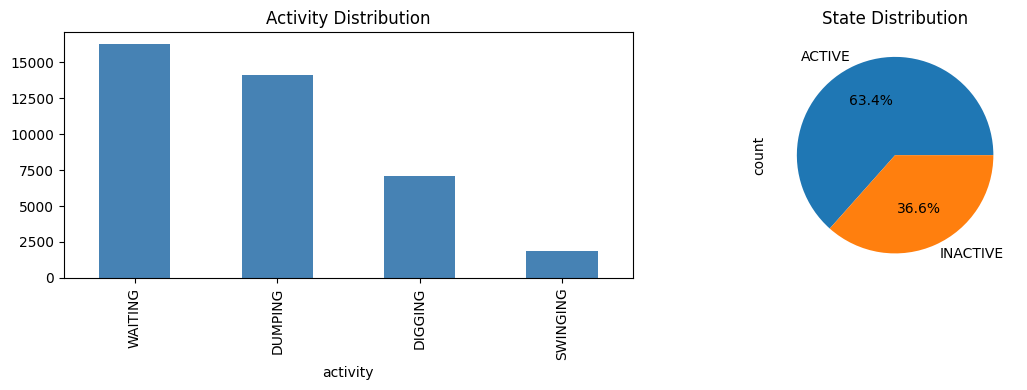

In [34]:
# Activity breakdown plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["activity"].value_counts().plot.bar(ax=axes[0], title="Activity Distribution", color="steelblue")
df["state"].value_counts().plot.pie(ax=axes[1], title="State Distribution", autopct="%1.1f%%")
plt.tight_layout()
plt.show()

In [35]:
# Save output
df.to_json("output.json", orient="records", lines=True)
df.to_csv("output.csv", index=False)
print("Saved → output.json and output.csv")

Saved → output.json and output.csv
